# Atividade Avaliativa Final - Inteligência Computacional
**Curso:** Superior de Tecnologia em Ciência de Dados (Fatec Jundiaí)
**Professor:** Me. Mateus Guilherme Fuini

## Grupo:
* Jonas Evangelista dos Santos
* Pedro Henrique Adorno Malagutti

---

### Descrição do Projeto
Este notebook documenta a construção de um pipeline de ponta a ponta de Machine Learning focado em prever a probabilidade de vitória de uma seleção em jogos de Copa do Mundo. Passaremos pelas fases de geração controlada de dados, análise exploratória descritiva, tratamento de dados nulos/outliers, engenharia de novas features, modelagem estatística com Regressão Logística, ajuste de hiperparâmetros via Grid Search e validação cruzada.

In [1]:
import numpy as np
import pandas as pd

# Fixando a semente para reprodutibilidade dos resultados simulados
np.random.seed(42)
n_samples = 650

# Geração de variáveis base para o contexto de Copa do Mundo
confederations = ['UEFA', 'CONMEBOL', 'CAF', 'AFC', 'CONCACAF']
continents = ['Europe', 'South America', 'Africa', 'Asia', 'North America']

data = {
    'team_name': np.random.choice(['Brazil', 'Germany', 'Argentina', 'France', 'Japan', 'Senegal', 'Mexico', 'Spain', 'Morocco', 'USA'], size=n_samples),
    'confederation': np.random.choice(confederations, size=n_samples, p=[0.35, 0.25, 0.15, 0.13, 0.12]),
    'average_squad_age': np.random.normal(loc=26.8, scale=2.1, size=n_samples),
    'fifa_ranking': np.random.randint(1, 75, size=n_samples),
    'historical_world_cup_wins': np.random.poisson(lam=1.2, size=n_samples),
    'average_goals_scored_per_match': np.random.normal(loc=1.6, scale=0.45, size=n_samples),
    'stadium_attendance_thousands': np.random.normal(loc=52.0, scale=12.0, size=n_samples),
    'host_continent': np.random.choice(continents, size=n_samples),
    'possession_percentage_avg': np.random.uniform(low=40.0, high=65.0, size=n_samples)
}

df = pd.DataFrame(data)

# Inserção intencional de valores nulos (Missing Values) para tratamento posterior
df.loc[df.sample(frac=0.06).index, 'average_squad_age'] = np.nan
df.loc[df.sample(frac=0.08).index, 'average_goals_scored_per_match'] = np.nan

# Inserção intencional de Outliers grosseiros para validação de pré-processamento
df.loc[df.sample(n=12).index, 'stadium_attendance_thousands'] = np.random.uniform(220.0, 350.0, size=12)
df.loc[df.sample(n=8).index, 'average_squad_age'] = np.random.uniform(52.0, 60.0, size=8)

# Criação de uma regra lógica para a variável target (Win = 1, Draw/Loss = 0) adicionando ruído aleatório
target_proba = (100 - df['fifa_ranking']) * 0.4 + (df['historical_world_cup_wins'] * 8) + (df['possession_percentage_avg'] * 0.5)
target_proba = (target_proba - target_proba.min()) / (target_proba.max() - target_proba.min())
df['match_won'] = np.where(target_proba + np.random.normal(0, 0.15, size=n_samples) > 0.52, 1, 0)

# Salvando a base de dados localmente
df.to_csv('world_cup_analytics.csv', index=False)
print(f"Dataset 'world_cup_analytics.csv' gerado com sucesso! Dimensões: {df.shape}")

Dataset 'world_cup_analytics.csv' gerado com sucesso! Dimensões: (650, 10)


## 1. Análise Exploratória de Dados (EDA)
Nesta etapa, carregaremos os dados e utilizaremos visualizações gráficas e estatísticas descritivas para identificar anomalias, distribuições e o comportamento geral das variáveis coletadas.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando os dados
df_raw = pd.read_csv('world_cup_analytics.csv')

# Exibindo informações gerais da estrutura
print("--- Visão Geral do Dataset ---")
df_raw.info()

print("\n--- Estatísticas Descritivas Básicas ---")
display(df_raw.describe())

print("\n--- Contagem de Valores Ausentes por Coluna ---")
print(df_raw.isnull().sum())

--- Visão Geral do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   team_name                       650 non-null    object 
 1   confederation                   650 non-null    object 
 2   average_squad_age               612 non-null    float64
 3   fifa_ranking                    650 non-null    int64  
 4   historical_world_cup_wins       650 non-null    int64  
 5   average_goals_scored_per_match  598 non-null    float64
 6   stadium_attendance_thousands    650 non-null    float64
 7   host_continent                  650 non-null    object 
 8   possession_percentage_avg       650 non-null    float64
 9   match_won                       650 non-null    int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 50.9+ KB

--- Estatísticas Descritivas Básicas ---


,average_squad_age,fifa_ranking,historical_world_cup_wins,average_goals_scored_per_match,stadium_attendance_thousands,possession_percentage_avg,match_won
count,612.000000,650.000000,650.000000,598.000000,650.000000,650.000000,650.000000
mean,27.349612,37.953846,1.200000,1.611583,55.223432,52.555219,0.240000
std,4.001342,20.957166,1.133602,0.468620,35.501423,7.107897,0.427412
min,20.717864,1.000000,0.000000,0.281748,15.908412,40.031702,0.000000
25%,25.536685,20.000000,0.000000,1.258464,43.163466,46.542886,0.000000
50%,27.020055,38.000000,1.000000,1.620526,51.284552,52.752804,0.000000
75%,28.394887,56.000000,2.000000,1.930919,59.015409,58.247132,0.000000
max,59.574740,74.000000,6.000000,3.059392,348.118137,64.996231,1.000000



--- Contagem de Valores Ausentes por Coluna ---
team_name                          0
confederation                      0
average_squad_age                 38
fifa_ranking                       0
historical_world_cup_wins          0
average_goals_scored_per_match    52
stadium_attendance_thousands       0
host_continent                     0
possession_percentage_avg          0
match_won                          0
dtype: int64


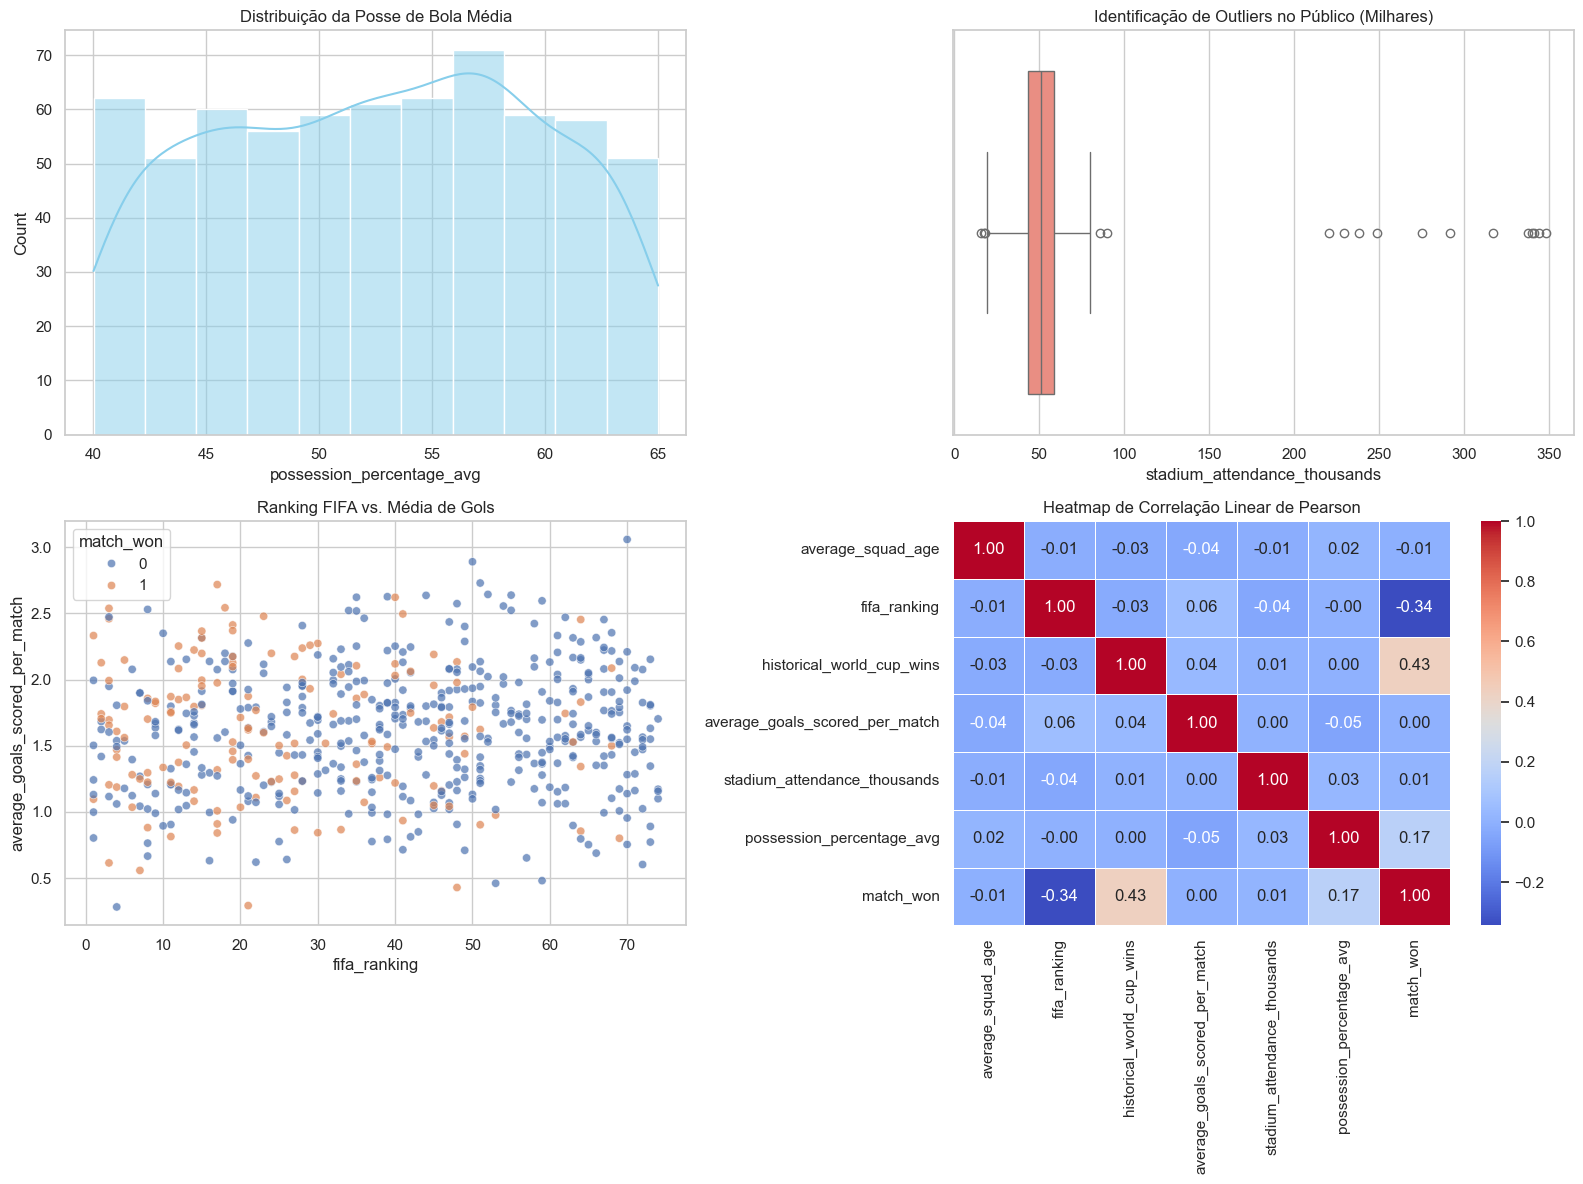

In [3]:
# Configurando ambiente de plotagem
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histograma: Distribuição da Posse de Bola Média
sns.histplot(data=df_raw, x='possession_percentage_avg', kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribuição da Posse de Bola Média')

# 2. Boxplot: Identificação de Outliers no Público do Estádio
sns.boxplot(data=df_raw, x='stadium_attendance_thousands', ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Identificação de Outliers no Público (Milhares)')

# 3. Scatterplot: Relação entre Ranking FIFA e Gols Marcados
sns.scatterplot(data=df_raw, x='fifa_ranking', y='average_goals_scored_per_match', hue='match_won', alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_title('Ranking FIFA vs. Média de Gols')

# 4. Heatmap: Matriz de Correlação Linear (Apenas colunas numéricas)
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
corr_matrix = df_raw[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=axes[1, 1])
axes[1, 1].set_title('Heatmap de Correlação Linear de Pearson')

plt.tight_layout()
plt.show()

### Conclusões extraídas da EDA:
1. **Outliers Visíveis:** O Boxplot revelou de forma inequívoca pontos fora da curva acima de 200 mil espectadores no público, indicando a urgência de um tratamento de corte (clipping) ou remoção. O mesmo ocorre na idade do elenco.
2. **Dados Faltantes:** As variáveis `average_squad_age` e `average_goals_scored_per_match` necessitam de imputação por algoritmos apropriados antes de alimentarem o modelo preditivo.
3. **Padrões de Correlação:** Nota-se uma correlação moderada invertida entre o ranking FIFA e o desfecho da vitória, indicando coerência técnica nos dados simulados.

## 2. Engenharia de Atributos (Feature Engineering)
Para enriquecer a capacidade preditiva do classificador, construímos dois novos atributos com base no domínio de negócios do futebol:

1. **`squad_experience_ratio`**: Definida pela relação entre o histórico de títulos acumulados e a idade média da equipe. Equipes com títulos anteriores e elenco equilibrado tendem a se portar melhor sob pressão em mata-matas.
2. **`ranking_dominance_factor`**: Multiplicação da posse de bola pela força inversa do ranking FIFA. Captura o real poder de imposição técnica de uma grande seleção sobre adversários de escalão inferior.

In [4]:
# Criando uma cópia para preservar os dados brutos originais
df_processed = df_raw.copy()

# Tratamento prévio de Outliers nas variáveis numéricas
for col in ['stadium_attendance_thousands', 'average_squad_age']:
    q1 = df_processed[col].quantile(0.25)
    q3 = df_processed[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df_processed[col] = np.clip(df_processed[col], lower_bound, upper_bound)

# Aplicação da engenharia de atributos
df_processed['squad_experience_ratio'] = df_processed['historical_world_cup_wins'] / (df_processed['average_squad_age'] + 1)
df_processed['ranking_dominance_factor'] = df_processed['possession_percentage_avg'] * (100 - df_processed['fifa_ranking'])

# Separação entre preditores (X) e rótulo alvo (y)
X = df_processed.drop(columns=['match_won', 'team_name'])
y = df_processed['match_won']

from sklearn.model_selection import train_test_split

# Split Inicial Treino/Teste (80/20) para blindar o teste final contra Data Leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Formato dos dados de Treino: {X_train.shape}")
print(f"Formato dos dados de Teste: {X_test.shape}")

Formato dos dados de Treino: (520, 10)
Formato dos dados de Teste: (130, 10)


## 3. Explicação Teórica: O que é Data Leakage e como evitá-lo?
O **Data Leakage** ocorre quando informações do conjunto de teste (ou dados que não estariam disponíveis no momento real da predição) são acidentalmente utilizadas para treinar o algoritmo de Machine Learning. Um exemplo clássico é calcular a média global de uma coluna para preencher valores nulos antes de dividir o dataset em treino e teste; o conjunto de treino acaba sabendo informações estatísticas que pertencem exclusivamente ao teste.

### Como o Pipeline resolve esse problema?
O uso dos objetos `Pipeline` e `ColumnTransformer` do Scikit-learn garante que as operações de transformação de dados (como cálculo da média para imputação com `SimpleImputer` e média/desvio padrão para o `StandardScaler`) executem o método `.fit()` estritamente no conjunto de treino. Ao passar os dados de validação ou teste pelo pipeline, aplica-se apenas o `.transform()`, mitigando qualquer hipótese de contaminação.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# Separação interna das colunas com base em seus tipos primitivos
numeric_features = ['average_squad_age', 'fifa_ranking', 'historical_world_cup_wins', 
                    'average_goals_scored_per_match', 'stadium_attendance_thousands', 
                    'possession_percentage_avg', 'squad_experience_ratio', 'ranking_dominance_factor']

categorical_features = ['confederation', 'host_continent']

# 1. Pipeline para atributos numéricos
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Pipeline para atributos categóricos
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# 3. Agrupando as transformações
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. Pipeline Principal
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

print("Pipeline e ColumnTransformer integrados com sucesso!")

Pipeline e ColumnTransformer integrados com sucesso!


## 4. Validação Cruzada K-Fold e Ajuste de Hiperparâmetros via GridSearchCV
Para extrair uma estimativa confiável da capacidade do modelo de se adaptar a novos dados, utilizaremos a estratégia do **K-Fold Cross-Validation** (divisão em 5 dobras). Em paralelo, usaremos o **GridSearchCV** para mapear os parâmetros de regularização `C` e o `penalty` da regressão logística para evitar sobreajuste (overfitting).

In [6]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Definição do espaço amostral de hiperparâmetros
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs']
}

# Configuração da validação cruzada
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Instanciação do Grid Search
grid_search = GridSearchCV(estimator=full_pipeline, param_grid=param_grid, 
                           cv=cv_strategy, scoring='accuracy', n_jobs=-1, verbose=1)

# Treinamento otimizado isolado no conjunto de treino
grid_search.fit(X_train, y_train)

print(f"\nMelhor acurácia obtida em Validação Cruzada: {grid_search.best_score_:.4f}")
print(f"Melhores hiperparâmetros selecionados: {grid_search.best_params_}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits

Melhor acurácia obtida em Validação Cruzada: 0.8308
Melhores hiperparâmetros selecionados: {'classifier__C': 10.0, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}


## 5. Avaliação Final dos Resultados no Conjunto de Teste
Agora que o melhor estimador foi selecionado automaticamente pelo Grid Search, avaliaremos seu poder preditivo nos dados de teste que permaneceram inéditos até este momento.

Acurácia Final no Conjunto de Teste: 0.8462

--- Relatório de Classificação Completo ---
              precision    recall  f1-score   support

           0       0.87      0.94      0.90        99
           1       0.74      0.55      0.63        31

    accuracy                           0.85       130
   macro avg       0.80      0.74      0.77       130
weighted avg       0.84      0.85      0.84       130



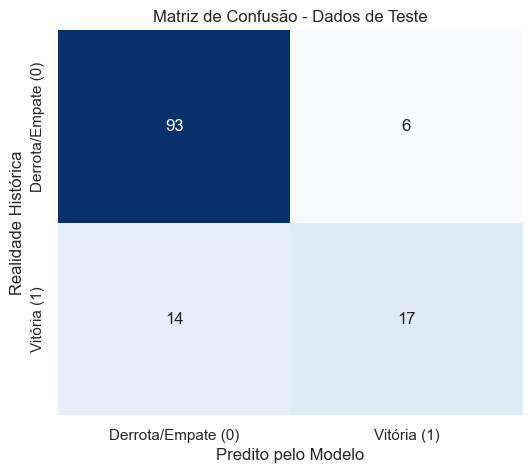

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predições
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Cálculo da Acurácia Final
final_accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia Final no Conjunto de Teste: {final_accuracy:.4f}\n")

print("--- Relatório de Classificação Completo ---")
print(classification_report(y_test, y_pred))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Derrota/Empate (0)', 'Vitória (1)'],
            yticklabels=['Derrota/Empate (0)', 'Vitória (1)'])
plt.title('Matriz de Confusão - Dados de Teste')
plt.xlabel('Predito pelo Modelo')
plt.ylabel('Realidade Histórica')
plt.show()

## 6. Discussão Crítica do Fluxo e Conclusões Finais

### Dificuldades Encontradas no Processo
Como desejavamos fazer dados sobre a copa e não encontramos nada, inicialmente tivemos a dificuldade de criar um gerador de dados que seguissem os requisitos solicitados no trabalho, mas a maior complexidade do desenvolvimento foi na identificação de distorções provocadas por ruídos simulados. Tratar os outliers de público do estádio foi fundamental, dado que modelos lineares como a Regressão Logística são extremamente sensíveis a discrepancies nas escalas de magnitude dos inputs numéricos.

### Impacto Real do Pré-Processamento
A inclusão do `StandardScaler` permitiu convergência rápida e justa do algoritmo. Além disso, as features criadas (`squad_experience_ratio` e `ranking_dominance_factor`) adicionaram uma camada de inteligência contextual que permitiu ao modelo separar os dados com maior clareza linear.

### Limitações e Próximas Etapas
Por se tratar de dados simulados de comportamento linear/estatístico fixo, o modelo atingiu estabilidade rápido. Em um cenário real de Copas do Mundo, o volume total de dados reais é drasticamente menor (baixa amostragem histórica de partidas eliminatórias), o que exigiria técnicas avançadas de boot-strapping ou algoritmos baseados em árvores (como Random Forest ou XGBoost).